## Set up

### Import Library

In [1]:
from pathlib import Path
import torch
import pandas as pd
import sys
import os

# go up two levels: Jupyter_notebook → scripts → project_root
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(project_root)


# reuse functions from your script
# from Archeived.main_predict import get_model, get_dataset, run_pred
from mst.inference.predictor import load_model, get_dataset_class, predict_batch


import warnings
warnings.simplefilter("ignore", UserWarning)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

/home/jovyan/work/MST/mst/models/extern/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/jovyan/work/MST/mst/models/extern/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/jovyan/work/MST/mst/models/extern/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


### Set Device - Path - Model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

run_dir = Path("/home/jovyan/work/MST/runs")

## For DINOv2
# run_folder = Path("DINOv2ViTS/DinoV2ClassifierSlice_Final")
# path_run = run_dir / run_folder

##For New Model
run_folder = Path("DINOv3ViTB")
checkpoint_name = "challenge_mstv3-vit_sch_CB_sub2_best.chkpt"
path_run = run_dir / run_folder / checkpoint_name

Load Model

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model("DinoV2ClassifierSlice", path_run, device)
model.to(device)
model.eval()

Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dinov3_main


DinoV2ClassifierSlice(
  (loss_func): CrossEntropyLoss()
  (auc_roc): ModuleDict(
    (train_): MulticlassAUROC()
    (val_): MulticlassAUROC()
    (test_): MulticlassAUROC()
  )
  (acc): ModuleDict(
    (train_): MulticlassAccuracy()
    (val_): MulticlassAccuracy()
    (test_): MulticlassAccuracy()
  )
  (encoder): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): Layer

### Load Test set

In [4]:
from mst.data.datasets.dataset_3d_odelia import ODELIA_Dataset3D

odelia_root = Path(project_root) / "mst" / "data" / "datasets" / "ODELIA_datasets"
ds_test = ODELIA_Dataset3D(path_root=odelia_root, split="test")
print(f"Loaded test samples: {len(ds_test)}")

Loaded test samples: 116


In [5]:
print(ds_test.__dict__.keys())

dict_keys(['path_root', 'path_root_data', 'split', 'sequence', 'transform', 'df', 'item_pointers'])


In [6]:
target_uid = "02F4A1FB_left"

idx = ds_test.item_pointers.index(target_uid)
sample = ds_test[idx]

In [7]:
batch = {}
for k, v in sample.items():
    if torch.is_tensor(v):
        batch[k] = v.unsqueeze(0).to(device)
    else:
        batch[k] = v


In [8]:
batch

{'uid': '02F4A1FB_left',
 'source': tensor([[[[[-0.6288, -0.6288, -0.6288,  ..., -0.6288, -0.6288, -0.6288],
            [-0.6288, -0.6288, -0.6288,  ..., -0.6288, -0.6288, -0.6288],
            [-0.6288, -0.6288, -0.6288,  ..., -0.6288, -0.6288, -0.6288],
            ...,
            [-0.5868, -0.6288, -0.6288,  ...,  1.1775,  0.9464,  0.9464],
            [-0.5868, -0.6078, -0.6498,  ...,  0.9254,  0.8624,  0.9674],
            [-0.6078, -0.6078, -0.6288,  ...,  0.8414,  0.8414,  0.9884]],
 
           [[-0.6288, -0.6288, -0.6288,  ..., -0.6288, -0.6288, -0.6288],
            [-0.6288, -0.6288, -0.6288,  ..., -0.6288, -0.6288, -0.6288],
            [-0.6288, -0.6288, -0.6288,  ..., -0.6288, -0.6288, -0.6288],
            ...,
            [-0.6078, -0.5448, -0.4818,  ...,  1.1565,  0.9044,  0.9044],
            [-0.5868, -0.5028, -0.4818,  ...,  0.9884,  0.7574,  0.7364],
            [-0.5028, -0.4397, -0.4818,  ...,  1.0514,  0.6314,  0.5264]],
 
           [[-0.6288, -0.6288, -0.628

In [9]:
batch["source"].shape

torch.Size([1, 1, 32, 224, 224])

In [10]:
pred = predict_batch(model, batch, device=device).cpu()
#probs = torch.softmax(pred, dim=-1).cpu()
pred_class = torch.argmax(pred, dim=1)

print(f"Pred is {pred}")
print(f"Predicted class is {pred_class}")

print("GT:", batch["target"].item())
print("Predicted class:", pred_class.item())
print("Probabilities:", pred.squeeze().numpy())


Pred is tensor([[0.5569, 0.2027, 0.2404]])
Predicted class is tensor([0])
GT: 0
Predicted class: 0
Probabilities: [0.5569339  0.20269623 0.24036995]


In [11]:
with torch.no_grad():
    logits = model(batch["source"].cpu())
    prob = torch.softmax(logits, dim=-1).cpu()#[0]
predicted_class = logits.argmax(dim=-1).item()

print(f"Logits: {logits}")
print(f"Probabilities: {prob}")
print(f"Predicted class from logits: {predicted_class}")

Logits: tensor([[1.0683, 0.0576, 0.2281]], device='cuda:0')
Probabilities: tensor([[0.5569, 0.2027, 0.2404]])
Predicted class from logits: 0


In [12]:
prob.detach().cpu().tolist()

[[0.5569338798522949, 0.20269623398780823, 0.24036994576454163]]

In [13]:
model.eval()

with torch.no_grad():
    logits_predict = model(
        batch["source"],
        src_key_padding_mask=batch.get("src_key_padding_mask")
    )

    # simulate perturbation step 0
    current = batch["source"].clone()

    logits_pert0 = model(
        current,
        src_key_padding_mask=batch.get("src_key_padding_mask")
    )

print(torch.allclose(logits_predict, logits_pert0, atol=1e-6))
print((logits_predict - logits_pert0).abs().max())

True
tensor(0., device='cuda:0')


In [14]:
print(batch["source"].shape)
print(current.shape)
print(torch.equal(batch["source"], current))

torch.Size([1, 1, 32, 224, 224])
torch.Size([1, 1, 32, 224, 224])
True


In [15]:
print(batch.get("src_key_padding_mask"))

None


## Create Confusion Matrix

### Import File

In [16]:
import pandas as pd
file_name = '/home/jovyan/work/MST/results/DINOv3ViTB/predictions/results.csv'
df = pd.read_csv(file_name)
df.head(), df.columns

(                          UID  GT  NN   NN_conf    prob_0    prob_1    prob_2
 0   ODELIA_BRAID1_0246_1_left   0   0  0.740634  0.740634  0.223199  0.036166
 1   ODELIA_TRICKS_0067_1_left   2   2  0.944761  0.030828  0.024411  0.944761
 2  ODELIA_BRAID1_0246_1_right   1   0  0.690749  0.690749  0.254271  0.054979
 3  ODELIA_TRICKS_0067_1_right   0   0  0.590814  0.590814  0.216409  0.192777
 4   ODELIA_BRAID1_0187_1_left   0   0  0.660276  0.660276  0.304888  0.034837,
 Index(['UID', 'GT', 'NN', 'NN_conf', 'prob_0', 'prob_1', 'prob_2'], dtype='object'))

### Normalized

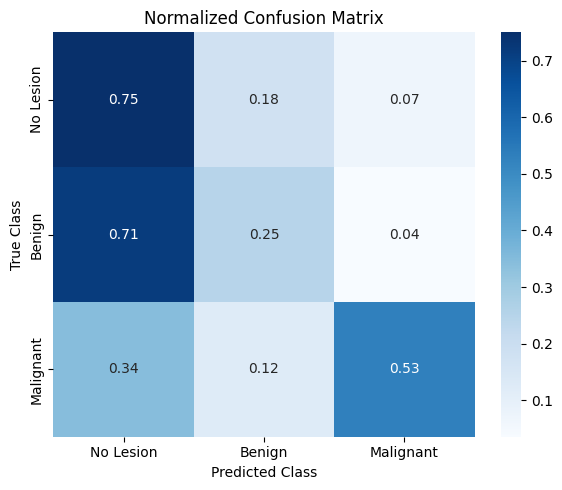

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load results
df = pd.read_csv(file_name)

# Ground truth and predictions
y_true = df["GT"]
y_pred = df["NN"]

# Class labels
labels = [0, 1, 2]
class_names = ["No Lesion", "Benign", "Malignant"]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Normalized confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()

# Save for thesis
plt.savefig("Confusion Matrix/v3_confusion_matrix_normalized_withheading.jpg")
plt.show()

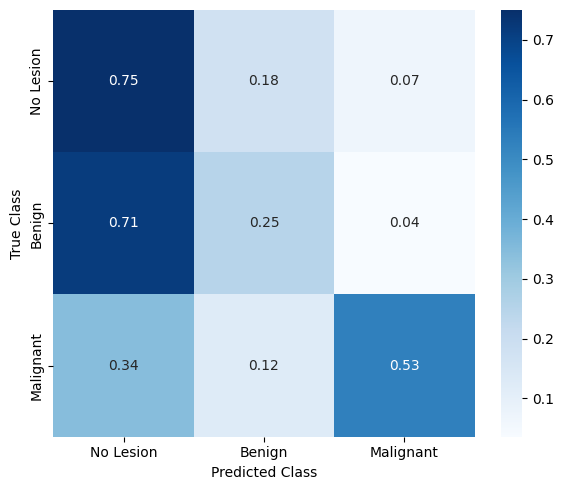

In [18]:
# Normalize confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

# plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig("Confusion Matrix/v3_confusion_matrix_normalized.jpg")
plt.show()

### Absolute

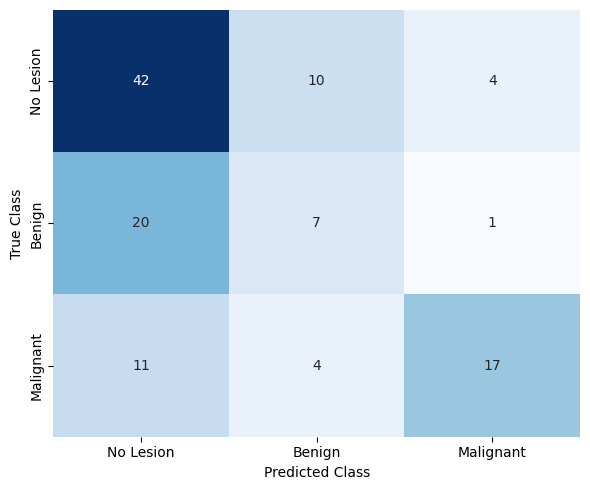

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load results
df = pd.read_csv(file_name)

y_true = df["GT"]
y_pred = df["NN"]

labels = [0,1,2]
class_names = ["No Lesion", "Benign", "Malignant"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

# plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig("Confusion Matrix/v3_confusion_matrix_counts.jpg")
plt.show()

### Combined

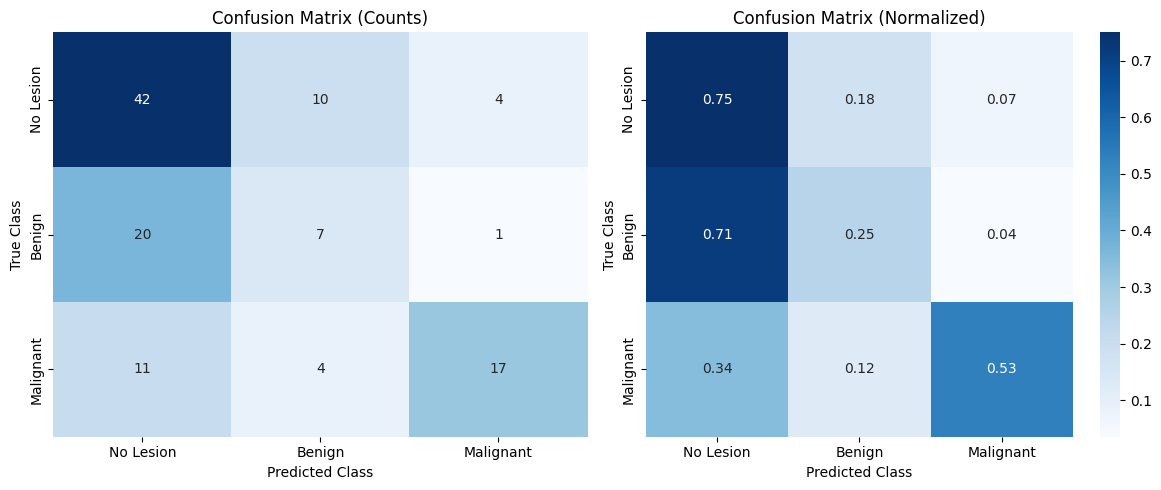

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Load prediction results
df = pd.read_csv(file_name)

# Ground truth and predictions
y_true = df["GT"]
y_pred = df["NN"]

# Class labels
labels = [0,1,2]
class_names = ["No Lesion", "Benign", "Malignant"]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Normalize by row (true class)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Create figure
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Absolute confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")

# Normalized confusion matrix
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    ax=axes[1]
)

axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("True Class")

plt.tight_layout()

# Save figure
plt.savefig("Confusion Matrix/v3_confusion_matrix_combined.jpg")

plt.show()

## Create AUC-ROC

({0: np.float64(0.6913690476190476),
  1: np.float64(0.6887175324675324),
  2: np.float64(0.8139880952380952),
  'micro': np.float64(0.7801724137931034),
  'macro': np.float64(0.7369678126932591)},
 'Confusion Matrix/v3_roc_multiclass_mst.jpg')

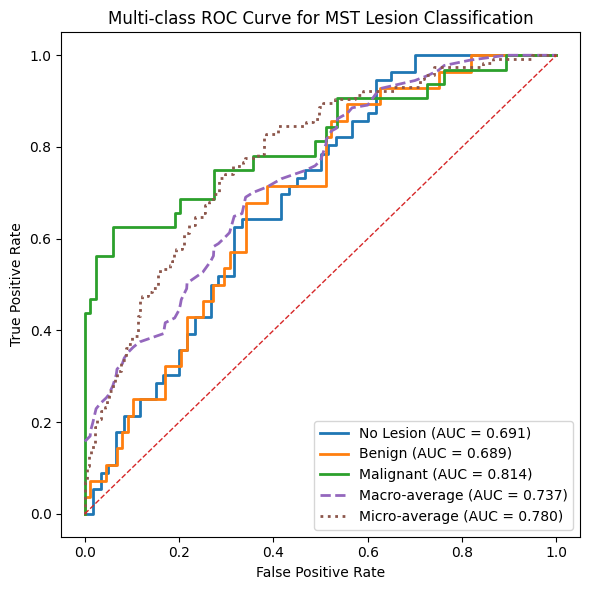

In [21]:
# Compute macro- and micro-average ROC/AUC and generate a publication-quality ROC plot

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Load data
df = pd.read_csv(file_name)

# Ground truth and probabilities
y_true = df["GT"].values
y_score = df[["prob_0","prob_1","prob_2"]].values

classes = [0,1,2]
class_names = {0:"No Lesion", 1:"Benign", 2:"Malignant"}

# Binarize labels for one-vs-rest ROC
y_true_bin = label_binarize(y_true, classes=classes)

# Compute ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
# Aggregate all FPR points
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))

# Interpolate TPR for each class at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# --- Publication-quality plot ---
plt.figure(figsize=(6,6))

# Plot individual classes
for i in range(len(classes)):
    plt.plot(
        fpr[i], 
        tpr[i], 
        linewidth=2,
        color=f"C{i}",
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

# Plot macro and micro averages
plt.plot(
    fpr["macro"], 
    tpr["macro"], 
    linestyle='--', 
    linewidth=2,
    color="C4",
    label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})'
)

plt.plot(
    fpr["micro"], 
    tpr["micro"], 
    linestyle=':', 
    linewidth=2,
    color="C5",
    label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})'
)

# Chance line
plt.plot([0,1],[0,1], linestyle='--', linewidth=1, color='C3')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for MST Lesion Classification")
plt.legend(loc="lower right")
plt.tight_layout()

# Save figure for thesis
out_path = "Confusion Matrix/v3_roc_multiclass_mst.jpg"
plt.savefig(out_path)

roc_auc, out_path

### ROC only Micro and Macro Average

({0: np.float64(0.6913690476190476),
  1: np.float64(0.6887175324675324),
  2: np.float64(0.8139880952380952),
  'micro': np.float64(0.7801724137931034),
  'macro': np.float64(0.7369678126932591)},
 'Confusion Matrix/v3_roc_multiclass_mst_onlyavg.jpg')

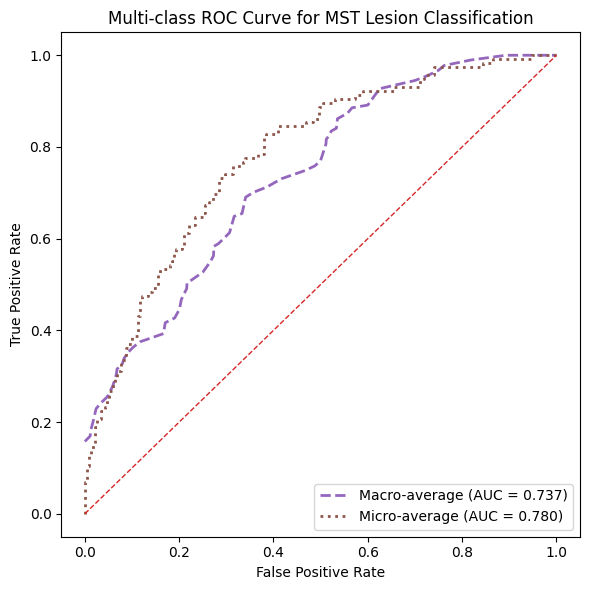

In [22]:
# --- Publication-quality plot ---
plt.figure(figsize=(6,6))

# # Plot individual classes
# for i in range(len(classes)):
#     plt.plot(
#         fpr[i], 
#         tpr[i], 
#         linewidth=2,
#         color=f"C{i}",
#         label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
#     )

# Plot macro and micro averages
plt.plot(
    fpr["macro"], 
    tpr["macro"], 
    linestyle='--', 
    linewidth=2,
    color="C4",
    label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})'
)

plt.plot(
    fpr["micro"], 
    tpr["micro"], 
    linestyle=':', 
    linewidth=2,
    color="C5",
    label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})'
)

# Chance line
plt.plot([0,1],[0,1], linestyle='--', linewidth=1, color='C3')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for MST Lesion Classification")
plt.legend(loc="lower right")
plt.tight_layout()

# Save figure for thesis
out_path = "Confusion Matrix/v3_roc_multiclass_mst_onlyavg.jpg"
plt.savefig(out_path)

roc_auc, out_path

### Only Individual Class

({0: np.float64(0.6913690476190476),
  1: np.float64(0.6887175324675324),
  2: np.float64(0.8139880952380952),
  'micro': np.float64(0.7801724137931034),
  'macro': np.float64(0.7369678126932591)},
 'Confusion Matrix/v3_roc_multiclass_mst_individual.jpg')

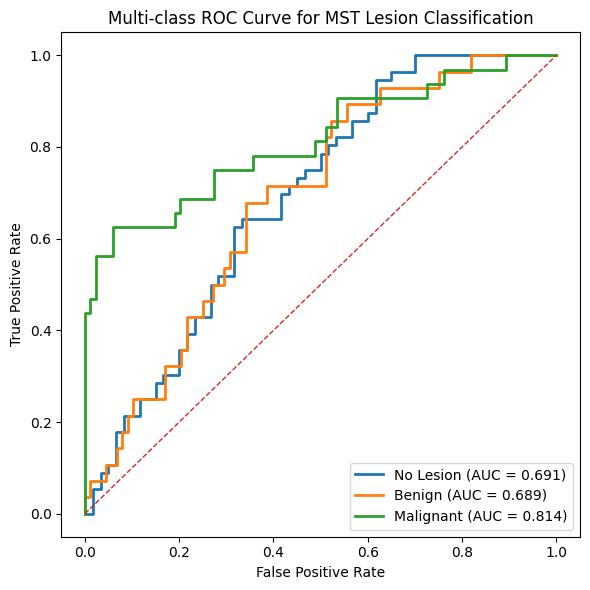

In [23]:
# --- Publication-quality plot ---
plt.figure(figsize=(6,6))

# Plot individual classes
for i in range(len(classes)):
    plt.plot(
        fpr[i], 
        tpr[i], 
        linewidth=2,
        color=f"C{i}",
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

# # Plot macro and micro averages
# plt.plot(
#     fpr["macro"], 
#     tpr["macro"], 
#     linestyle='--', 
#     linewidth=2,
#     color="C4",
#     label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})'
# )

# plt.plot(
#     fpr["micro"], 
#     tpr["micro"], 
#     linestyle=':', 
#     linewidth=2,
#     color="C5",
#     label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})'
# )

# Chance line
plt.plot([0,1],[0,1], linestyle='--', linewidth=1, color='C3')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for MST Lesion Classification")
plt.legend(loc="lower right")
plt.tight_layout()

# Save figure for thesis
out_path = "Confusion Matrix/v3_roc_multiclass_mst_individual.jpg"
plt.savefig(out_path)

roc_auc, out_path

## LOOK list of file name

In [24]:
import pandas as pd

# Load your file
df = pd.read_csv(file_name)

# Correct predictions
correct = df[df["GT"] == df["NN"]]

# Incorrect predictions
incorrect = df[df["GT"] != df["NN"]]

# # ---- SAVE BOTH ----
# correct_grouped = correct.groupby("GT")["UID"].apply(list)
# incorrect_grouped = incorrect.groupby("GT")["UID"].apply(list)

# Group correct samples with full info
correct_grouped = correct.groupby("GT").apply(
    lambda x: x[["UID", "GT", "NN"]].to_dict(orient="records")
)

# Group incorrect samples with full info
incorrect_grouped = incorrect.groupby("GT").apply(
    lambda x: x[["UID", "GT", "NN"]].to_dict(orient="records")
)

# Save
correct_grouped.to_json("Confusion Matrix/v3_correct_full.json", indent=2)
incorrect_grouped.to_json("Confusion Matrix/v3_incorrect_full.json", indent=2)
# correct_grouped.to_json("Confusion Matrix/v3_correct_uids_per_class.json", indent=2)
# incorrect_grouped.to_json("Confusion Matrix/v3_incorrect_uids_per_class.json", indent=2)

/tmp/ipykernel_29882/3931133022.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correct_grouped = correct.groupby("GT").apply(
/tmp/ipykernel_29882/3931133022.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  incorrect_grouped = incorrect.groupby("GT").apply(


In [25]:
# grouped = correct.groupby("GT")["UID"].apply(list)

# # Save to JSON or CSV
# grouped.to_json("Confusion Matrix/v3_correct_uids_per_class.json", indent=2)